# ML: Foundations Final Group Project: Flight Delays

> _Predicting high ATC pre-departure delay days at European airports using EUROCONTROL operational data and METAR weather._

\*\*Team: Alejandro Zapata, Alex Garcia, Andres Befeler, Javier Cruz, Jose Miguel Reyes, Nicolas Gonzalez

\*\*GitHub repository: https://github.com/agarcia246/Machine_learning_Project

**Dataset:** EUROCONTROL Performance Review Unit Open Performance Data (2008-2026 Q1), enriched with METAR daily weather (`meteostat`).

---

## Abstract

European air-traffic-management delay costs the EU economy an estimated **€10 billion** per year and contributes meaningfully to avoidable aviation CO₂. Using publicly-available EUROCONTROL daily airport-level data, monthly arrival-sequencing and vertical-flight-efficiency tables, country-level en-route delay decomposition by 17 cause codes, and external METAR weather, we frame two coupled tasks on the row definition `(airport, date)`:

1. **Classification** — predict whether tomorrow will be a "high delay day" for a given airport, defined as `delay_per_dep ≥ Q75` of that airport's trailing-365-day distribution.
2. **Regression** — predict the magnitude of `delay_per_dep` directly.

We compare several classifiers (dummy baseline, logistic regression, tree ensembles including Random Forest and HistGradientBoosting, with optional LightGBM when its native library loads), tune a probability threshold on validation to maximize F1, evaluate on a strict time-based test split, plot calibration curves for the champion model, and leave regression on `delay_per_dep` plus permutation/SHAP interpretation to teammate sections.


## 1. Setup/Imports


In [223]:
from pathlib import Path
import warnings

from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)


RANDOM_STATE = 42

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"


OSError: dlopen(/Users/josemiguelreyesalegria/Desktop/Machine_learning_Project/venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/josemiguelreyesalegria/Desktop/Machine_learning_Project/venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt

## 2. Load Raw CSVs

We create `read_concat()` because all of the folders in data have multiple csv files, each for a different year(range from 2016 to 2026). This function enables our program to handle them into a single pandas DataFrame.


In [224]:
def read_concat(folder):
    files = sorted(Path(folder).glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs found in {folder}")
    
    file_dataframes = []
    for f in files:
        file_dataframes.append(pd.read_csv(f, low_memory=False))

    return pd.concat(file_dataframes, ignore_index=True)


airport_traffic = read_concat(DATA_DIR / "airport_traffic")
atc_delays = read_concat(DATA_DIR / "atc_pre_departure_delays")
ert = read_concat(DATA_DIR / "ert_dly_fir")
asma = read_concat(DATA_DIR / "asma_additional_time")
vfe = read_concat(DATA_DIR / "vertical_flight_efficiency")


Before merging, we need to analyze the available columns and their type to keep consistency and facilitate the merge.


In [ ]:
airport_traffic.info()


<class 'pandas.DataFrame'>
RangeIndex: 1129233 entries, 0 to 1129232
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   YEAR           1129233 non-null  int64  
 1   MONTH_NUM      1129233 non-null  int64  
 2   MONTH_MON      1129233 non-null  str    
 3   FLT_DATE       1129233 non-null  str    
 4   APT_ICAO       1129233 non-null  str    
 5   APT_NAME       1129233 non-null  str    
 6   STATE_NAME     1129233 non-null  str    
 7   FLT_DEP_1      1129233 non-null  int64  
 8   FLT_ARR_1      1129233 non-null  int64  
 9   FLT_TOT_1      1129233 non-null  int64  
 10  FLT_DEP_IFR_2  335237 non-null   float64
 11  FLT_ARR_IFR_2  335237 non-null   float64
 12  FLT_TOT_IFR_2  335237 non-null   float64
dtypes: float64(3), int64(5), str(5)
memory usage: 151.0 MB


In [226]:
atc_delays.info()


<class 'pandas.DataFrame'>
RangeIndex: 1144593 entries, 0 to 1144592
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   YEAR           1144593 non-null  int64  
 1   MONTH_NUM      1144593 non-null  int64  
 2   MONTH_MON      1144593 non-null  str    
 3   FLT_DATE       1144593 non-null  str    
 4   APT_ICAO       1144593 non-null  str    
 5   APT_NAME       1144593 non-null  str    
 6   STATE_NAME     1144593 non-null  str    
 7   FLT_DEP_1      1144593 non-null  int64  
 8   FLT_DEP_IFR_2  215709 non-null   float64
 9   DLY_ATC_PRE_2  215709 non-null   float64
 10  FLT_DEP_3      863548 non-null   float64
 11  DLY_ATC_PRE_3  863548 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 144.2 MB


In [227]:
ert.info()


<class 'pandas.DataFrame'>
RangeIndex: 208877 entries, 0 to 208876
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              208877 non-null  int64  
 1   MONTH_NUM         208877 non-null  int64  
 2   MONTH_MON         208877 non-null  str    
 3   FLT_DATE          208877 non-null  str    
 4   ENTITY_NAME       208877 non-null  str    
 5   ENTITY_TYPE       208877 non-null  str    
 6   FLT_ERT_1         208877 non-null  int64  
 7   DLY_ERT_1         89291 non-null   float64
 8   DLY_ERT_A_1       89291 non-null   float64
 9   DLY_ERT_C_1       89291 non-null   float64
 10  DLY_ERT_D_1       89291 non-null   float64
 11  DLY_ERT_E_1       89291 non-null   float64
 12  DLY_ERT_G_1       89291 non-null   float64
 13  DLY_ERT_I_1       89291 non-null   float64
 14  DLY_ERT_M_1       89291 non-null   float64
 15  DLY_ERT_N_1       89291 non-null   float64
 16  DLY_ERT_O_1       89291 non-nul

In [228]:
asma.info()


<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEAR                9996 non-null   int64  
 1   MONTH_NUM           9996 non-null   int64  
 2   MONTH_MON           9996 non-null   str    
 3   APT_ICAO            9996 non-null   str    
 4   APT_NAME            9996 non-null   str    
 5   STATE_NAME          9996 non-null   str    
 6   TF                  8396 non-null   float64
 7   VALID_FL            8396 non-null   float64
 8   NO_REF              8396 non-null   float64
 9   TOTAL_REF_NB_FL     8396 non-null   float64
 10  TOTAL_REF_TIME_MIN  8280 non-null   float64
 11  TOTAL_ADD_TIME_MIN  8280 non-null   float64
 12  COMMENT             1716 non-null   str    
dtypes: float64(6), int64(2), str(5)
memory usage: 1.3 MB


In [229]:
vfe.info()


<class 'pandas.DataFrame'>
RangeIndex: 138876 entries, 0 to 138875
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   YEAR                            138876 non-null  int64  
 1   MONTH_NUM                       138876 non-null  int64  
 2   MONTH_MON                       138876 non-null  str    
 3   APT_ICAO                        138876 non-null  str    
 4   APT_NAME                        138876 non-null  str    
 5   STATE_NAME                      138876 non-null  str    
 6   NBR_FLIGHTS_DESCENT             138876 non-null  int64  
 7   TOT_DIST_LEVEL_NM_DESCENT       138876 non-null  float64
 8   TOT_DIST_LVL_NM_DESC_BLW_70     138876 non-null  float64
 9   TOT_TIME_LEVEL_SECONDS_DESCENT  138876 non-null  int64  
 10  TOT_TIME_LEVEL_SEC_DESC_BLW_70  138876 non-null  int64  
 11  MEDIAN_CDO_ALT                  138876 non-null  float64
 12  NBR_CDO_FLIGHTS            

Based on these findings, we can see that there are 3 dataframes that have `FLT_DATE`, which are **airport_traffic**, **atc_delays**, and **ert**. The problem is that all three of them are categorized as `str`, so we will convert them into `datetime64`. We also normalize the time to midnight so that we can merge on days and not have merge conflicts because of differing time.

For example, without normalization: `2024-01-01 00:00:00` and `2024-01-01 12:00:00` would be treated as different days.

Additionally, for all `str` columns, we convert it into `string` (which is more consistent). And also we strip the strings in order to remove all trailing white space to ensure that all text columns are clean, consistent, and safe to use for merging, grouping, and modeling.

Avoiding cases like `"JFK" =! "JFK "` to get `"JFK" = "JFK"`


In [230]:
for df in [airport_traffic, atc_delays, ert]:
    df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"], errors="coerce").dt.normalize()

for df in [airport_traffic, atc_delays, ert, asma, vfe]:
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in obj_cols:
        df[col] = df[col].astype("string").str.strip()

# Unified integer month/year keys (ASMA uses "01", VFE uses "1", etc.)
for df in [airport_traffic, atc_delays, asma, vfe, ert]:
    if "MONTH_NUM" in df.columns:
        df["MONTH_NUM"] = pd.to_numeric(df["MONTH_NUM"], errors="coerce").astype("Int64")
    if "YEAR" in df.columns:
        df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")



## 3. Building the panel


For now, we are going to merge the columns `atc_delays` and `airport_traffic`. But before doing so, we are going to check the columns that they have in common so we don't end up with duplicate columns in our merged panel.


In [231]:
set(atc_delays.columns).intersection(set(airport_traffic.columns))


{'APT_ICAO',
 'APT_NAME',
 'FLT_DATE',
 'FLT_DEP_1',
 'FLT_DEP_IFR_2',
 'MONTH_MON',
 'MONTH_NUM',
 'STATE_NAME',
 'YEAR'}

After knowing the shared columns, we also need to see all of the other columns that are not in common


In [232]:
only_in_airport = set(airport_traffic.columns) - set(atc_delays.columns)
only_in_atc = set(atc_delays.columns) - set(airport_traffic.columns)

print("Only in airport_traffic:", only_in_airport)
print("Only in atc_delays:", only_in_atc)


Only in airport_traffic: {'FLT_ARR_IFR_2', 'FLT_TOT_1', 'FLT_ARR_1', 'FLT_TOT_IFR_2'}
Only in atc_delays: {'FLT_DEP_3', 'DLY_ATC_PRE_2', 'DLY_ATC_PRE_3'}


Now that we know the columns that are in common and unique to each column, we are going to decide which ones to take into consideration before merging. For both DataFrames, we are going to keep `FLT_DATE` and `APT_ICAO` which are used together to uniquely identify each airport at each different day. And be used as a composite key to merge the datasets.


In [233]:
traffic_cols = [
    "FLT_DATE", "YEAR", "MONTH_NUM", "MONTH_MON",
    "APT_ICAO", "APT_NAME", "STATE_NAME",
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
]
atc_cols = [
    "FLT_DATE", "APT_ICAO",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]


In [234]:
print(f'atc: {atc_delays.duplicated(subset=["APT_ICAO","FLT_DATE"]).sum()}')
print(f'airport: {airport_traffic.duplicated(subset=["APT_ICAO","FLT_DATE"]).sum()}')


atc: 0
airport: 1


Inspect `airport_traffic` `APT_ICAO` and `FLT_DATE` duplicate before dropping


In [235]:
airport_traffic[
    airport_traffic.duplicated(subset=["APT_ICAO", "FLT_DATE"], keep=False)
].sort_values(["APT_ICAO", "FLT_DATE"])


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
640884,2022,1,JAN,2022-01-01,EBAW,Antwerp,Belgium,9,8,17,NaN,NaN,NaN
640885,2022,1,JAN,2022-01-01,EBAW,Antwerp,Belgium,9,8,17,NaN,NaN,NaN


Because the duplicates do not differ in values, it is safe to just drop the duplicate from `airport_traffic`. We make a copy of both DataFrames and merge them using `APT_ICAO` and `FLT_DATE` together


In [236]:
traffic = airport_traffic[traffic_cols].drop_duplicates(subset=["APT_ICAO", "FLT_DATE"]).copy()
atc = atc_delays[atc_cols].copy()
panel = traffic.merge(atc, on=["APT_ICAO", "FLT_DATE"], how="left")


In [237]:
panel.info()


<class 'pandas.DataFrame'>
RangeIndex: 1129232 entries, 0 to 1129231
Data columns (total 16 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   FLT_DATE       1129232 non-null  datetime64[us]
 1   YEAR           1129232 non-null  Int64         
 2   MONTH_NUM      1129232 non-null  Int64         
 3   MONTH_MON      1129232 non-null  string        
 4   APT_ICAO       1129232 non-null  string        
 5   APT_NAME       1129232 non-null  string        
 6   STATE_NAME     1129232 non-null  string        
 7   FLT_DEP_1      1129232 non-null  int64         
 8   FLT_ARR_1      1129232 non-null  int64         
 9   FLT_TOT_1      1129232 non-null  int64         
 10  FLT_DEP_IFR_2  335237 non-null   float64       
 11  FLT_ARR_IFR_2  335237 non-null   float64       
 12  FLT_TOT_IFR_2  335237 non-null   float64       
 13  DLY_ATC_PRE_2  202524 non-null   float64       
 14  FLT_DEP_3      846347 non-null   float64     

The next step is to ensure every numeric column is actually numeric including invalid types. For example, if any null value is presented as string `"N/A"`, `errors = "coerce"` ensures that it is converted to `NaN` and not treated as an object.


In [238]:
numeric_cols = [
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]

for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"]).reset_index(drop=True)
panel.head()


,FLT_DATE,YEAR,MONTH_NUM,MONTH_MON,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,DLY_ATC_PRE_2,FLT_DEP_3,DLY_ATC_PRE_3
0,2024-01-01,2024,1,JAN,BIKF,Keflavik,Iceland,76,62,138,NaN,NaN,NaN,NaN,12.0,7.0
1,2024-01-02,2024,1,JAN,BIKF,Keflavik,Iceland,86,86,172,NaN,NaN,NaN,NaN,11.0,0.0
2,2024-01-03,2024,1,JAN,BIKF,Keflavik,Iceland,81,78,159,NaN,NaN,NaN,NaN,15.0,0.0
3,2024-01-04,2024,1,JAN,BIKF,Keflavik,Iceland,75,79,154,NaN,NaN,NaN,NaN,12.0,5.0
4,2024-01-05,2024,1,JAN,BIKF,Keflavik,Iceland,84,79,163,NaN,NaN,NaN,NaN,13.0,0.0


### Path A — data enrichment plan (team)

We extend the base panel with **ASMA**, **VFE**, **ERT**, and **METAR** (see `PROJECT_CHECKLIST.md`).

**Leakage defaults for modeling features:**

- Monthly ASMA / VFE → attach **previous calendar month** to each airport-day (teammates implement in Phase 3–4).
- Country ERT → attach **previous calendar day** per `STATE_NAME` (Phase 5).
- Airport lags in §7 already use `shift(1)`.


## 3b. Enrich panel (ASMA, VFE, ERT, METAR)

**Status:** Phases **0–2** below prepare keys and lookup tables. Phases **3–6** (joins + weather) are in `PROJECT_CHECKLIST.md` for teammates.

Base `panel` remains **airport_traffic + atc_pre_departure_delays**; enrichment adds columns without changing row grain `(APT_ICAO, FLT_DATE)`.


In [239]:
# --- Phase 2: calendar keys on daily panel ---
panel["cal_year"] = panel["FLT_DATE"].dt.year.astype("int64")
panel["cal_month"] = panel["FLT_DATE"].dt.month.astype("int64")

assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0, "panel must stay one row per airport-day"

# --- Phase 2: monthly tables (one row per airport-month), prefixed for later joins ---
ASMA_DROP = ["APT_NAME", "STATE_NAME", "MONTH_MON", "COMMENT"]
asma_m = asma.drop(columns=[c for c in ASMA_DROP if c in asma.columns]).copy()
asma_m = asma_m.rename(
    columns={c: f"asma_{c}" for c in asma_m.columns if c not in {"APT_ICAO", "YEAR", "MONTH_NUM"}}
)

VFE_DROP = ["APT_NAME", "STATE_NAME", "MONTH_MON", "AIRPORT_NAME"]
vfe_m = vfe.drop(columns=[c for c in VFE_DROP if c in vfe.columns]).copy()
vfe_m = vfe_m.rename(
    columns={c: f"vfe_{c}" for c in vfe_m.columns if c not in {"APT_ICAO", "YEAR", "MONTH_NUM"}}
)

# --- Phase 2: ERT at country (FIR) x day ---
ERT_KEY_COLS = {"ENTITY_NAME", "ENTITY_TYPE", "FLT_DATE", "YEAR", "MONTH_NUM", "MONTH_MON"}
ert_country = ert.loc[ert["ENTITY_TYPE"] == "COUNTRY (FIR)"].copy()
ert_country = ert_country.rename(
    columns={c: f"ert_{c}" for c in ert_country.columns if c not in ERT_KEY_COLS}
)
for col in ert_country.columns:
    if col.startswith("ert_"):
        ert_country[col] = pd.to_numeric(ert_country[col], errors="coerce")

# --- Phase 2: STATE_NAME <-> ERT ENTITY_NAME (extend MANUAL_STATE_NAME_MAP as needed) ---
MANUAL_STATE_NAME_MAP = {
    "Republic of North Macedonia": "North Macedonia",
    "Turkey": "Turkiye",
}

panel_states = pd.Series(panel["STATE_NAME"].dropna().unique(), name="STATE_NAME")
ert_states = pd.Series(ert_country["ENTITY_NAME"].dropna().unique(), name="ENTITY_NAME")

state_name_map = panel_states.to_frame().merge(
    ert_states.to_frame(),
    left_on="STATE_NAME",
    right_on="ENTITY_NAME",
    how="outer",
    indicator=True,
)

unmapped_panel = state_name_map.loc[state_name_map["_merge"] == "left_only", "STATE_NAME"].tolist()
unmapped_ert = state_name_map.loc[state_name_map["_merge"] == "right_only", "ENTITY_NAME"].tolist()

print("Panel rows:", len(panel), "| ASMA months:", len(asma_m), "| VFE months:", len(vfe_m), "| ERT country-days:", len(ert_country))
print("cal_year range:", int(panel["cal_year"].min()), "-", int(panel["cal_year"].max()))
print("Unmapped STATE_NAME (panel only):", unmapped_panel)
print("Unmapped ENTITY_NAME (ERT only):", unmapped_ert)
print("Manual map (panel -> ERT):", MANUAL_STATE_NAME_MAP)
display(state_name_map.sort_values(["_merge", "STATE_NAME"]).head(25))



Panel rows: 1129232 | ASMA months: 9996 | VFE months: 138876 | ERT country-days: 163961
cal_year range: 2016 - 2026
Unmapped STATE_NAME (panel only): ['Israel', 'Luxembourg', 'Montenegro', 'Morocco', 'Republic of North Macedonia', 'Serbia']
Unmapped ENTITY_NAME (ERT only): ['North Macedonia', 'Portugal Continental', 'Portugal Santa Maria', 'Serbia and Montenegro', 'Serbia/Montenegro', 'Spain Canarias', 'Spain Canaries', 'Spain Continental', 'The former Yugoslav Republic of Macedonia', 'Turkey', 'Turkiye', 'UK Continental', 'UK Oceanic']
Manual map (panel -> ERT): {'Republic of North Macedonia': 'North Macedonia', 'Turkey': 'Turkiye'}


,STATE_NAME,ENTITY_NAME,_merge
19,Israel,<NA>,left_only
23,Luxembourg,<NA>,left_only
26,Montenegro,<NA>,left_only
27,Morocco,<NA>,left_only
35,Republic of North Macedonia,<NA>,left_only
37,Serbia,<NA>,left_only
29,<NA>,North Macedonia,right_only
33,<NA>,Portugal Continental,right_only
34,<NA>,Portugal Santa Maria,right_only
38,<NA>,Serbia and Montenegro,right_only


#### Step 6: Merge ASMA into the airport-day panel

ASMA is defined at airport-month granularity.  
We merge it using airport, year, and month keys, while preserving the airport-day structure of the panel.

To avoid leakage, ASMA features are shifted by one calendar month after the merge.


In [240]:
# Rename ASMA calendar keys to match panel keys
asma_m = asma_m.rename(columns={
    "YEAR": "cal_year",
    "MONTH_NUM": "cal_month"
})

# Merge ASMA
panel = panel.merge(
    asma_m,
    on=["APT_ICAO", "cal_year", "cal_month"],
    how="left"
)

# Lag ASMA features by one month per airport
asma_cols = [c for c in panel.columns if c.startswith("asma_")]

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"])

for col in asma_cols:
    panel[col] = panel.groupby("APT_ICAO")[col].shift(1)

# QA check
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 7: Merge VFE into the airport-day panel

VFE is also monthly at airport level.

We merge using airport, year, and month keys and apply a one-period lag to prevent future information leakage.


In [241]:
# Prepare VFE keys
vfe_m = vfe_m.rename(columns={"YEAR": "cal_year", "MONTH_NUM": "cal_month"}).copy()

# Remove identical duplicate airport-month rows
vfe_m = vfe_m.drop_duplicates(subset=["APT_ICAO", "cal_year", "cal_month"]).copy()
assert vfe_m.duplicated(subset=["APT_ICAO", "cal_year", "cal_month"]).sum() == 0

# Merge
panel = panel.merge(
    vfe_m,
    on=["APT_ICAO", "cal_year", "cal_month"],
    how="left",
    validate="m:1"
)

# Lag VFE features
vfe_cols = [c for c in panel.columns if c.startswith("vfe_")]

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"])

for col in vfe_cols:
    panel[col] = panel.groupby("APT_ICAO")[col].shift(1)

# QA
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 8: Merge ERT regional delay features

ERT provides regional delay information at country-day granularity.

We align country names between datasets and merge ERT features using state name and flight date.

To avoid leakage, ERT features are shifted by one day.


In [242]:
panel["FLT_DATE"] = pd.to_datetime(panel["FLT_DATE"], errors="coerce").dt.normalize()

ert_country["FLT_DATE"] = pd.to_datetime(ert_country["FLT_DATE"], errors="coerce")
if ert_country["FLT_DATE"].dt.tz is not None:
    ert_country["FLT_DATE"] = ert_country["FLT_DATE"].dt.tz_convert(None)
ert_country["FLT_DATE"] = ert_country["FLT_DATE"].dt.normalize()

In [243]:
# Apply manual country-name fixes
ert_country["ENTITY_NAME"] = ert_country["ENTITY_NAME"].replace({
    v: k for k, v in MANUAL_STATE_NAME_MAP.items()
})

# Merge ERT
panel = panel.merge(
    ert_country,
    left_on=["STATE_NAME", "FLT_DATE"],
    right_on=["ENTITY_NAME", "FLT_DATE"],
    how="left"
)

# Lag ERT features by one day
ert_cols = [c for c in panel.columns if c.startswith("ert_")]

panel = panel.sort_values(["STATE_NAME", "FLT_DATE"])

for col in ert_cols:
    panel[col] = panel.groupby("STATE_NAME")[col].shift(1)

# QA
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 9: Final panel quality checks

After enrichment, we verify that:

- the panel still contains one row per airport-day,
- the joins did not duplicate observations,
- and the enriched features contain valid missingness patterns.


In [244]:
print("Panel shape:", panel.shape)

print(
    "Duplicate airport-days:",
    panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum()
)

display(
    panel[
        [c for c in panel.columns if c.startswith(("asma_", "vfe_", "ert_"))]
    ].isna().mean().sort_values(ascending=False).head(20)
)

Panel shape: (1129232, 69)
Duplicate airport-days: 0


asma_TOTAL_REF_TIME_MIN    0.777256
asma_TOTAL_ADD_TIME_MIN    0.777256
asma_TF                    0.774270
asma_VALID_FL              0.774270
asma_TOTAL_REF_NB_FL       0.774270
asma_NO_REF                0.774270
ert_DLY_ERT_A_1            0.373936
ert_DLY_ERT_C_1            0.373936
ert_DLY_ERT_D_1            0.373936
ert_DLY_ERT_E_1            0.373936
ert_DLY_ERT_G_1            0.373936
ert_DLY_ERT_I_1            0.373936
ert_DLY_ERT_M_1            0.373936
ert_DLY_ERT_N_1            0.373936
ert_DLY_ERT_O_1            0.373936
ert_DLY_ERT_P_1            0.373936
ert_DLY_ERT_1              0.373936
ert_DLY_ERT_S_1            0.373936
ert_DLY_ERT_T_1            0.373936
ert_DLY_ERT_V_1            0.373936
dtype: float64

## 4. Defining the regression target


Now that we have the data loaded and merged we are going to define and create one of the targets we have. So we are going find a ratio of all the minutes of delay divided the amount of planes that departed that day. In order to know what could be an approximation of minutes delayed per plane. We are going to do an analysis to know what should be the minimum value of departured airplanes in an airport, due to the fact that and airport with a few traffic could give really high numbers, even though only one flight was delayed, and this would generate a noise.


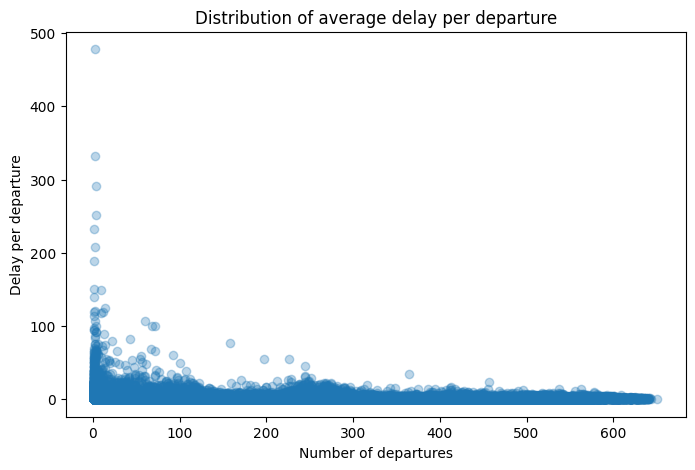

In [245]:
plt.figure(figsize=(8,5))


plt.scatter(
    panel["FLT_DEP_3"],
    panel["DLY_ATC_PRE_3"] / panel["FLT_DEP_3"],
    alpha=0.3
)


plt.xlabel("Number of departures")
plt.ylabel("Delay per departure")


plt.title("Distribution of average delay per departure")


plt.show()

In this graph we can see the ratio per airport of delay per departure compared with number of departures. And we can observe that many airports have near to 0 departures, and have a delay per departure really big, compared to other numbers makes it look really skewed and noise. So we are going to assume that around 50 departures is the minimum that we are going to take into account.


In [246]:
MIN_DEPARTURES = 50

panel["delay_per_dep"] = np.where(
    panel["FLT_DEP_3"] >= MIN_DEPARTURES,
    panel["DLY_ATC_PRE_3"] / panel["FLT_DEP_3"],
    np.nan
)


## 5. EDA


In [247]:
panel.shape
panel.info()
panel.isna().mean().sort_values(ascending=False).head(20)
panel["FLT_DATE"].min()
panel["FLT_DATE"].max()
panel["APT_ICAO"].nunique()


<class 'pandas.DataFrame'>
Index: 1129232 entries, 474328 to 157876
Data columns (total 70 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   FLT_DATE                            1129232 non-null  datetime64[us]
 1   YEAR_x                              1129232 non-null  Int64         
 2   MONTH_NUM_x                         1129232 non-null  Int64         
 3   MONTH_MON_x                         1129232 non-null  string        
 4   APT_ICAO                            1129232 non-null  string        
 5   APT_NAME                            1129232 non-null  string        
 6   STATE_NAME                          1129232 non-null  string        
 7   FLT_DEP_1                           1129232 non-null  int64         
 8   FLT_ARR_1                           1129232 non-null  int64         
 9   FLT_TOT_1                           1129232 non-null  int64         
 10  FLT_DE

336

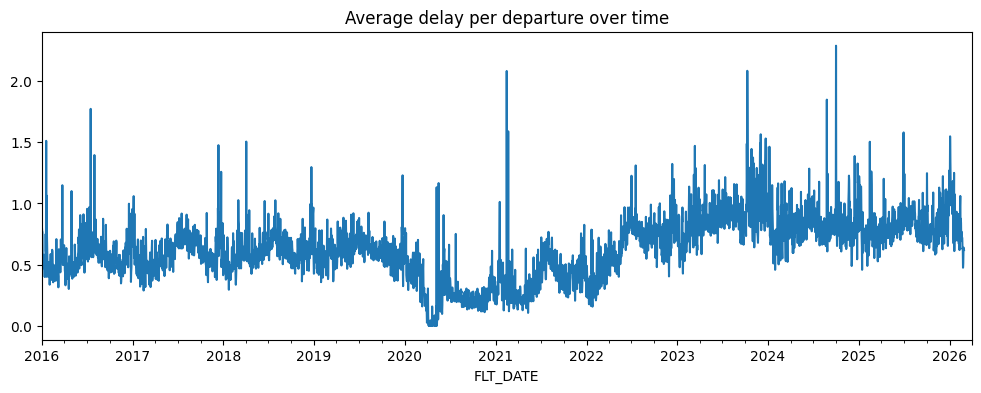

In [248]:
panel.groupby("FLT_DATE")["delay_per_dep"].mean().plot(figsize=(12, 4))
plt.title("Average delay per departure over time")
plt.show()


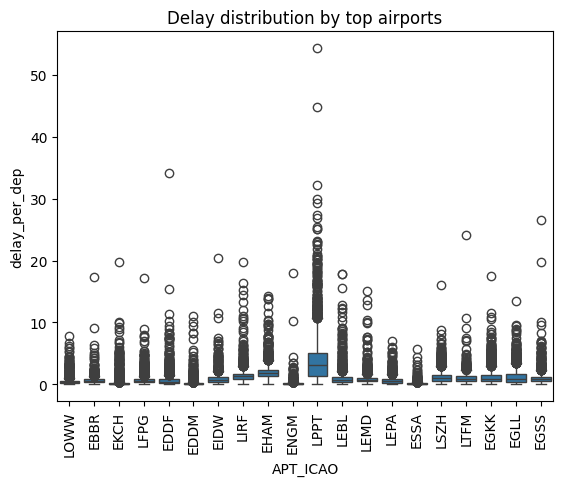

In [249]:
top_airports = (
    panel.groupby("APT_ICAO")["FLT_DEP_3"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

sns.boxplot(
    data=panel[panel["APT_ICAO"].isin(top_airports)],
    x="APT_ICAO",
    y="delay_per_dep"
)

plt.xticks(rotation=90)
plt.title("Delay distribution by top airports")
plt.show()


## 6. Build Classification Target


In [250]:
panel = panel.sort_values(["APT_ICAO","FLT_DATE"]).reset_index(drop=True)

panel["thresh"] = (
    panel.groupby("APT_ICAO")["delay_per_dep"]
    .transform(lambda s: s.shift(1).rolling(365, min_periods=60).quantile(0.75))
)

panel["y_reg"] = panel["delay_per_dep"]
panel["y_clf"] = (panel["delay_per_dep"] >= panel["thresh"]).astype("float")

panel.loc[
    panel["delay_per_dep"].isna() | panel["thresh"].isna(),
    "y_clf"
] = np.nan


## 7. Feature Engineering


In [251]:
df = panel.copy()
df = df[df["FLT_DEP_3"].fillna(0) >= MIN_DEPARTURES].copy()


In [252]:
df["cal_dow"] = df["FLT_DATE"].dt.dayofweek
df["cal_month"] = df["FLT_DATE"].dt.month
df["cal_week"] = df["FLT_DATE"].dt.isocalendar().week.astype(int)
df["cal_quarter"] = df["FLT_DATE"].dt.quarter
df["cal_is_weekend"] = (df["cal_dow"] >= 5).astype(int)
df["cal_is_month_start"] = df["FLT_DATE"].dt.is_month_start.astype(int)
df["cal_is_month_end"] = df["FLT_DATE"].dt.is_month_end.astype(int)


In [253]:
g = df.groupby("APT_ICAO", group_keys=False)

for lag in [1, 7, 14, 28]:
    df[f"lag_delay_per_dep_{lag}d"] = g["delay_per_dep"].shift(lag)




In [254]:
for window in [7, 30]:
    shifted_delay = g["delay_per_dep"].shift(1)
    shifted_dep = g["FLT_DEP_3"].shift(1)

    df[f"roll_delay_mean_{window}_d"] = (
        shifted_delay.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"roll_delay_std_{window}_d"] = (
        shifted_delay.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"roll_dep_mean_{window}_d"] = (
        shifted_dep.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .mean()
        .reset_index(level=0, drop=True)
    )


In [255]:
state_yday = (
    df.groupby(["STATE_NAME", "FLT_DATE"])["delay_per_dep"]
    .median()
    .reset_index()
    .rename(columns={"delay_per_dep": "net_state_med_delay"})
)

state_yday["FLT_DATE"] = state_yday["FLT_DATE"] + pd.Timedelta(days=1)

df = df.merge(state_yday, on=["STATE_NAME", "FLT_DATE"], how="left")


In [256]:
df = df[df["y_clf"].notna()].copy()
df["y_clf"] = df["y_clf"].astype(int)


## 8. Train/Val/Test Split


In [257]:
train = df[df["FLT_DATE"] <= "2022-12-31"].copy()
val = df[(df["FLT_DATE"] > "2022-12-31") & (df["FLT_DATE"] <= "2023-12-31")].copy()
test = df[df["FLT_DATE"] > "2023-12-31"].copy()

print(train.shape)
print(val.shape)
print(test.shape)


(164713, 90)
(27427, 90)
(62676, 90)


## 9. Select Features


In [258]:
drop_cols = [
    "y_clf", "y_reg", "thresh", "delay_per_dep",
    "DLY_ATC_PRE_3", "DLY_ATC_PRE_2",
    "FLT_DATE", "APT_NAME", "MONTH_MON",
]

feature_cols = []

for c in df.columns:
    if c not in drop_cols:
        feature_cols.append(c)

x_train = train[feature_cols]
y_train = train["y_clf"]

x_val = val[feature_cols]
y_val = val["y_clf"]

x_test = test[feature_cols]
y_test = test["y_clf"]



In [259]:
categorical_features = ["APT_ICAO", "STATE_NAME"]
categorical_features = [c for c in categorical_features if c in feature_cols]

numeric_features = [
    c for c in feature_cols
    if c not in categorical_features and pd.api.types.is_numeric_dtype(df[c])
]


## 10. Preprocessing Pipelines


In [260]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)


In [261]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),
    ]
)


## 11. Training Baselines and Models


In [262]:
models = {
    "dummy": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "logreg": Pipeline([
        ("pre", linear_preprocessor),
        ("model", LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "decision_tree": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "random_forest": Pipeline([
        ("pre", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=80, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "hist_gb": Pipeline([
        ("pre", tree_preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
}

try:
    from lightgbm import LGBMClassifier

    models["lgbm"] = Pipeline([
        ("pre", tree_preprocessor),
        (
            "model",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_estimators=400,
                learning_rate=0.05,
                num_leaves=63,
                subsample=0.8,
                colsample_bytree=0.8,
                verbose=-1,
            ),
        ),
    ])
except (ImportError, OSError):
    pass




In [263]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    fitted_models[name] = model
    proba = model.predict_proba(x_val)[:, 1]
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "brier": brier_score_loss(y_val, proba),
    })

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df




ValueError: The output of the 'num' transformer for column 'YEAR_y' has dtype Int64 and uses pandas.NA to represent null values. Storing this output in a numpy array can cause errors in downstream scikit-learn estimators, and inefficiencies. To avoid this problem you can (i) store the output in a pandas DataFrame by using ColumnTransformer.set_output(transform='pandas') or (ii) modify the input data or the 'num' transformer to avoid the presence of pandas.NA (for example by using pandas.DataFrame.astype).

## 12. Choosing best threshold

We pick the **champion classifier** by **average precision (PR-AUC) on validation** (more informative than ROC-AUC under class imbalance). We then search a probability threshold on the validation scores to **maximize F1** and reuse that fixed threshold on the held-out **test** period.


In [ ]:
CHAMPION_METRIC = "pr_auc"
champion_name = results_df.iloc[0]["model"]
champion = fitted_models[champion_name]

val_proba = champion.predict_proba(x_val)[:, 1]
test_proba = champion.predict_proba(x_test)[:, 1]

threshold_grid = np.linspace(0.01, 0.99, 198)
f1_val = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in threshold_grid]
t_star = float(threshold_grid[int(np.argmax(f1_val))])

val_pred_t = (val_proba >= t_star).astype(int)
test_pred_t = (test_proba >= t_star).astype(int)

print("champion:", champion_name)
print("val", CHAMPION_METRIC, float(results_df.loc[results_df["model"] == champion_name, CHAMPION_METRIC].iloc[0]))
print("t_star (F1-optimal on val):", round(t_star, 4))
print("val F1 @ t*:", round(f1_score(y_val, val_pred_t, zero_division=0), 4))
print("test F1 @ t*:", round(f1_score(y_test, test_pred_t, zero_division=0), 4))




champion: hist_gb
val pr_auc 0.5586238715229994
t_star (F1-optimal on val): 0.3334
val F1 @ t*: 0.5173
test F1 @ t*: 0.4201


## 13. Locked test evaluation (classification)

Model and threshold are frozen after validation tuning; metrics below are computed on **test** (`FLT_DATE` > 2023-12-31).


,test
roc_auc,0.605828
pr_auc,0.403279
brier,0.221516
precision,0.298458
recall,0.708991
f1,0.420079


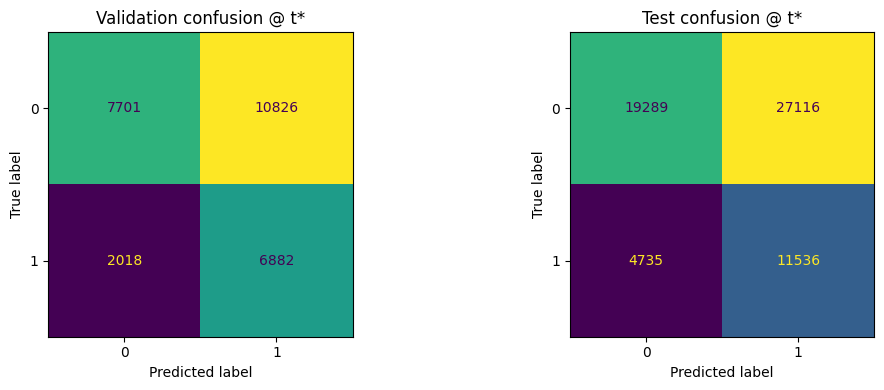

              precision    recall  f1-score   support

           0      0.803     0.416     0.548     46405
           1      0.298     0.709     0.420     16271

    accuracy                          0.492     62676
   macro avg      0.551     0.562     0.484     62676
weighted avg      0.672     0.492     0.515     62676



In [ ]:
clf_test_metrics = {
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
    "brier": brier_score_loss(y_test, test_proba),
    "precision": precision_score(y_test, test_pred_t, zero_division=0),
    "recall": recall_score(y_test, test_pred_t, zero_division=0),
    "f1": f1_score(y_test, test_pred_t, zero_division=0),
}
display(pd.Series(clf_test_metrics).to_frame("test"))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred_t, ax=ax[0], colorbar=False)
ax[0].set_title("Validation confusion @ t*")
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_t, ax=ax[1], colorbar=False)
ax[1].set_title("Test confusion @ t*")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred_t, digits=3))






## 14. Calibration (reliability)

We plot **reliability curves** for the **champion classifier** at the fixed threshold context: predicted probability vs empirical positive rate, using **quantile bins** so each bin has comparable support under imbalance. Compare **validation** and **test**; relate to the **Brier score** from §13.


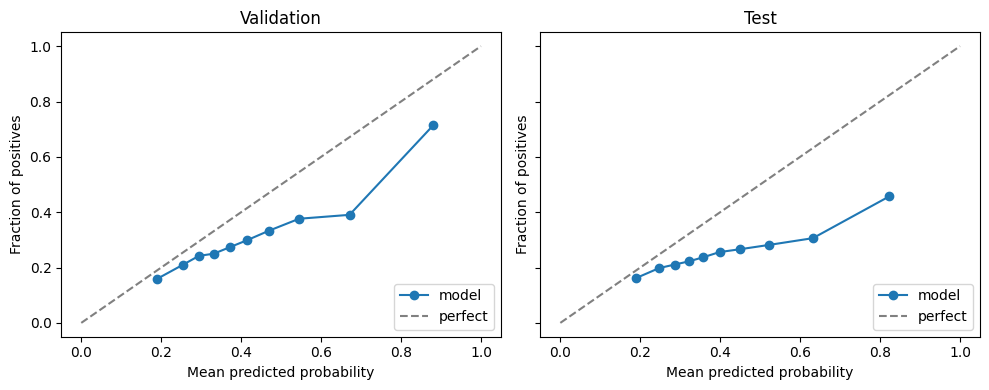

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, title, y_true, proba in [
    (axes[0], "Validation", y_val, val_proba),
    (axes[1], "Test", y_test, test_proba),
]:
    prob_true, prob_pred = calibration_curve(
        y_true, proba, n_bins=10, strategy="quantile"
    )
    ax.plot(prob_pred, prob_true, marker="o", label="model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



## 15. Regression (`delay_per_dep`)

We reuse the same feature matrix and temporal split as the classification task, but predict the continuous target `y_reg = delay_per_dep`. Model selection stays on the validation period only: models are sorted by validation RMSE, then the selected regressor is evaluated once on the locked test period.


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,random_forest,1.307910,0.406811,0.427854,1.138756,0.387801,0.363285
1,hist_gb,1.357539,0.402521,0.383611,1.135174,0.373260,0.367284
2,dummy_median,1.820771,0.709069,-0.108820,1.510243,0.625946,-0.119896


regression champion: random_forest
validation RMSE: 1.3079
test RMSE: 1.1388


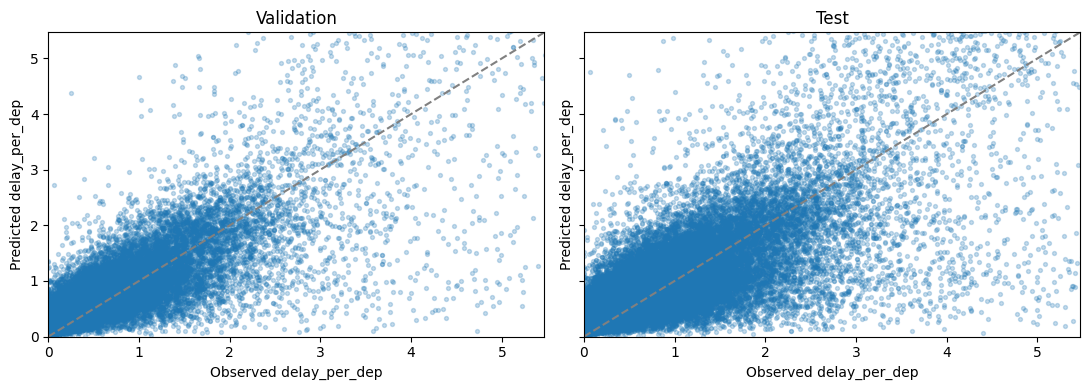

In [ ]:
y_train_r = train["y_reg"].values
y_val_r = val["y_reg"].values
y_test_r = test["y_reg"].values

reg_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_features),
    ]
)

reg_models = {
    "dummy_median": Pipeline([
        ("pre", reg_tree_preprocessor),
        ("model", DummyRegressor(strategy="median")),
    ]),
    "random_forest": Pipeline([
        ("pre", reg_tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
    "hist_gb": Pipeline([
        ("pre", reg_tree_preprocessor),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}


reg_models["lgbm"] = Pipeline([
    ("pre", reg_tree_preprocessor),
    (
        "model",
        LGBMRegressor(
            random_state=RANDOM_STATE,
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            verbose=-1,
        ),
    ),
])


def regression_scores(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


reg_results = []
fitted_reg_models = {}

for name, model in reg_models.items():
    model.fit(x_train, y_train_r)
    fitted_reg_models[name] = model

    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    row = {"model": name}
    row.update({f"val_{k}": v for k, v in regression_scores(y_val_r, val_pred).items()})
    row.update({f"test_{k}": v for k, v in regression_scores(y_test_r, test_pred).items()})
    reg_results.append(row)

reg_results_df = pd.DataFrame(reg_results).sort_values("val_rmse").reset_index(drop=True)
display(reg_results_df)

best_reg_name = reg_results_df.loc[0, "model"]
best_reg = fitted_reg_models[best_reg_name]
reg_val_pred = best_reg.predict(x_val)
reg_test_pred = best_reg.predict(x_test)

print("best regression:", best_reg_name)
print("validation RMSE:", round(reg_results_df.loc[0, "val_rmse"], 4))
print("test RMSE:", round(reg_results_df.loc[0, "test_rmse"], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

for ax, title, y_true, y_pred in [
    (axes[0], "Validation", y_val_r, reg_val_pred),
    (axes[1], "Test", y_test_r, reg_test_pred),
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=8)
    lims = [0, np.nanpercentile(np.concatenate([y_true, y_pred]), 99)]
    ax.plot(lims, lims, linestyle="--", color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(title)
    ax.set_xlabel("Observed delay_per_dep")
    ax.set_ylabel("Predicted delay_per_dep")

plt.tight_layout()
plt.show()


## 16. Interpretation — teammate section

**Placeholder.** Add **permutation importance** (e.g. `sklearn.inspection.permutation_importance`) on a validation subsample for the champion classifier, and **SHAP** summary plots for a tree-based model (champion or `hist_gb` proxy if the champion is logistic regression). Keep runtime reasonable (subsample rows, limit `n_repeats`).


In [ ]:
# TODO (teammate): permutation_importance(champion, x_val_sample, y_val_sample, scoring="average_precision", ...)
# TODO (teammate): shap.TreeExplainer on preprocessed features; shap.summary_plot(...)
pass



## 17. Temporal drift / robustness — teammate section

**Placeholder.** Quantify how metrics shift between **validation** (e.g. 2023) and **test** (2024+) or slice by calendar era (pre/post 2020) **without** peeking at test for tuning. Optionally add block-bootstrap CIs on validation or test with a clear note on clustering by airport/month.


In [ ]:
# TODO (teammate): e.g. compare val vs test PR-AUC for champion; or pre/post-2020 slices on val only
# TODO (teammate, optional): cluster bootstrap for PR-AUC / F1 at fixed t_star
pass



## Appendix: Optional stretch goals (for teammates)

Pick any subset aligned with the course rubric and remaining time.


Optional steps checklist:

0. **§15 Regression** — implement the stub in §15 (same features and split as §12–§14); report val/test RMSE, MAE, R² and name a regression champion.

1. **Re-enable / tune LightGBM** — install OpenMP on macOS (`brew install libomp`) if `import lightgbm` fails with `libomp.dylib`; then widen `n_estimators` / learning rate on validation only.
2. **Restore heavier models for the write-up** — increase `RandomForestClassifier`/`Regressor` `n_estimators` and boosting `max_iter` once runtime is acceptable; re-run end-to-end.
3. **METAR / weather** — daily weather via `meteostat` keyed by airport coordinates + date; document join keys and missing-data handling.
4. **Extra EUROCONTROL tables** — join **ASMA** / **VFE** (monthly → daily within month) and/or **ERT** (aggregate FIR to country-day, then to airport via `STATE_NAME`); spell out merge keys and leakage checks.
5. **Stacking / MLP** — only if required: small sklearn `MLPClassifier` on scaled features, or stacking on out-of-fold val predictions (watch leakage and runtime).
6. **Bootstrap uncertainty** — block bootstrap by `(APT_ICAO, year_month)` for CIs on PR-AUC or F1 at fixed `t_star`; state limitations.
7. **CO₂ narrative** — only with an explicit cited conversion factor from delay minutes to fuel/CO₂; otherwise keep qualitative.
8. **Abstract polish** — after (1)–(6), align the opening paragraph with what is actually in the notebook.
